## Cell 1 – Imports

In [163]:
import os, random, cv2, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm
from scipy.optimize import curve_fit   # for EpochPredictor

import albumentations as A
from albumentations.pytorch import ToTensorV2

import torchvision.models as models
import torch.nn.functional as F   # ADD THIS LINE


## Cell 2 – Config & Seed (Smart Epoch Budget)

In [164]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed()

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

IMG_SIZE   = 256
BATCH_SIZE = 48
LR         = 1e-3

# ── Smart epoch budget (replaces fixed EPOCHS = 5) ───────────────────────────
MAX_EPOCHS          = 30    # hard ceiling — will rarely be reached
MIN_EPOCHS          = 5     # never stop before this many epochs
EARLY_STOP_PATIENCE = 7     # stop if val_dice doesn't improve for N epochs
PLATEAU_PATIENCE    = 4     # epochs of flat gain before LR-drop / prune
PLATEAU_MIN_DELTA   = 1e-4  # minimum improvement that counts as "real progress"

DATA_PATH = "/kaggle/input/competitions/severstal-steel-defect-detection"


Device: cuda


## Cell 3 – Load CSV & Train/Val Split

In [165]:
df_full = pd.read_csv(os.path.join(DATA_PATH, "train.csv"))
print("Columns:", df_full.columns.tolist())
print("Shape:", df_full.shape)
print(df_full.head(3))

df_cls = df_full.copy()
df_cls["has_defect"] = df_cls["EncodedPixels"].notnull().astype(int)
df_cls = df_cls.groupby("ImageId")["has_defect"].max().reset_index()

train_ids, val_ids = train_test_split(
    df_cls,
    test_size=0.2,
    stratify=df_cls["has_defect"],
    random_state=42
)

train_ids = train_ids["ImageId"].values
val_ids   = val_ids["ImageId"].values
print(f"Train: {len(train_ids)}  Val: {len(val_ids)}")


Columns: ['ImageId', 'ClassId', 'EncodedPixels']
Shape: (7095, 3)
         ImageId  ClassId                                      EncodedPixels
0  0002cc93b.jpg        1  29102 12 29346 24 29602 24 29858 24 30114 24 3...
1  0007a71bf.jpg        3  18661 28 18863 82 19091 110 19347 110 19603 11...
2  000a4bcdd.jpg        1  37607 3 37858 8 38108 14 38359 20 38610 25 388...
Train: 5332  Val: 1334


## Cell 4 – RLE Decode & Mask Builder

In [166]:
def rle_decode(mask_rle, shape=(256, 1600)):
    """
    Decode run-length encoding to a binary mask.
    shape = (H, W)  <- consistent (height, width) convention.
    """
    if pd.isna(mask_rle):
        return np.zeros(shape, dtype=np.uint8)

    s = list(map(int, mask_rle.split()))
    starts, lengths = s[::2], s[1::2]
    starts = np.array(starts) - 1
    ends   = starts + lengths

    img = np.zeros(shape[0] * shape[1], dtype=np.uint8)
    for lo, hi in zip(starts, ends):
        img[lo:hi] = 1

    return img.reshape(shape[1], shape[0]).T


def build_mask(image_id, df):
    """Combine all class masks for one image into a single binary mask."""
    rows = df[df["ImageId"] == image_id]
    mask = np.zeros((256, 1600), dtype=np.uint8)

    for _, row in rows.iterrows():
        if pd.notnull(row["EncodedPixels"]):
            mask |= rle_decode(row["EncodedPixels"])

    return mask


## Cell 5 – Augmentation Pipelines

In [167]:
train_tfms = A.Compose([
    A.Resize(256, 256),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.Rotate(limit=15, p=0.5),
    A.RandomBrightnessContrast(p=0.5),
    A.GaussNoise(std_range=(0.01, 0.05), p=0.3),
    A.Normalize(mean=(0.485, 0.456, 0.406),
                std =(0.229, 0.224, 0.225)),
    ToTensorV2()
])

val_tfms = A.Compose([
    A.Resize(256, 256),
    A.Normalize(mean=(0.485, 0.456, 0.406),
                std =(0.229, 0.224, 0.225)),
    ToTensorV2()
])


## Cell 6 – Dataset

In [168]:
class SteelSegDataset(Dataset):
    def __init__(self, image_ids, df_full, transforms=None):
        self.image_ids  = image_ids
        self.df         = df_full
        self.transforms = transforms

    def __len__(self):
        return len(self.image_ids)

    def __getitem__(self, idx):
        img_id = self.image_ids[idx]
        img_path = os.path.join(DATA_PATH, "train_images", img_id)

        img = cv2.imread(img_path)
        if img is None:
            raise FileNotFoundError(f"Image not found: {img_path}")
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        mask = build_mask(img_id, self.df).astype(np.float32)

        if self.transforms:
            aug  = self.transforms(image=img, mask=mask)
            img  = aug["image"]
            mask = aug["mask"]

        mask = mask.unsqueeze(0).float()   # → (1, H, W)

        return img, mask

train_dataset = SteelSegDataset(train_ids, df_full, transforms=train_tfms)
val_dataset   = SteelSegDataset(val_ids,   df_full, transforms=val_tfms)
print(f"Train samples: {len(train_dataset)}  Val samples: {len(val_dataset)}")


Train samples: 5332  Val samples: 1334


## Cell 7 – DataLoaders

In [169]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE, shuffle=True,
    num_workers=0, pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE, shuffle=False,
    num_workers=0, pin_memory=True
)


## Cell 8 – EDA: Defect vs No Defect

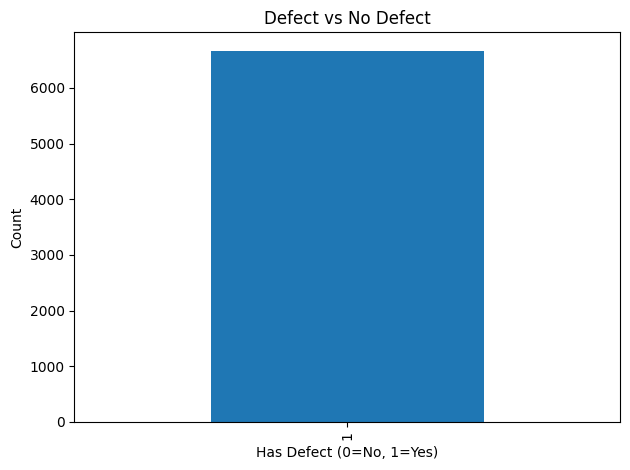

has_defect
1    1.0
Name: proportion, dtype: float64


In [170]:
df_cls["has_defect"].value_counts().plot(kind="bar", title="Defect vs No Defect")
plt.xlabel("Has Defect (0=No, 1=Yes)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

print(df_cls["has_defect"].value_counts(normalize=True))


## Cell 9 – EDA: Defect Class Distribution

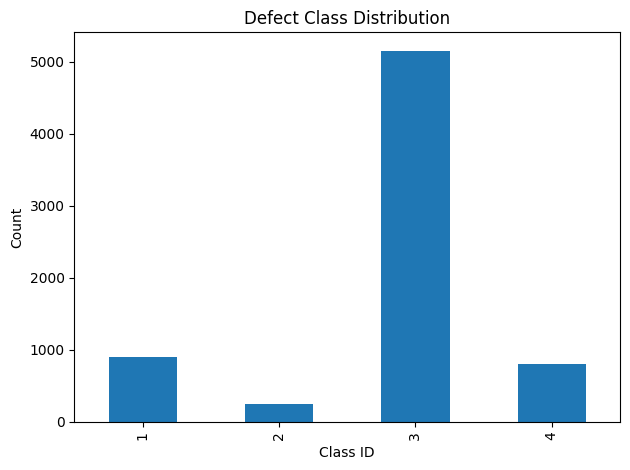

In [171]:
df_full["ClassId"].dropna().astype(int).value_counts().sort_index().plot(
    kind="bar", title="Defect Class Distribution"
)
plt.xlabel("Class ID")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


## Cell 10 – Visualise Train Samples

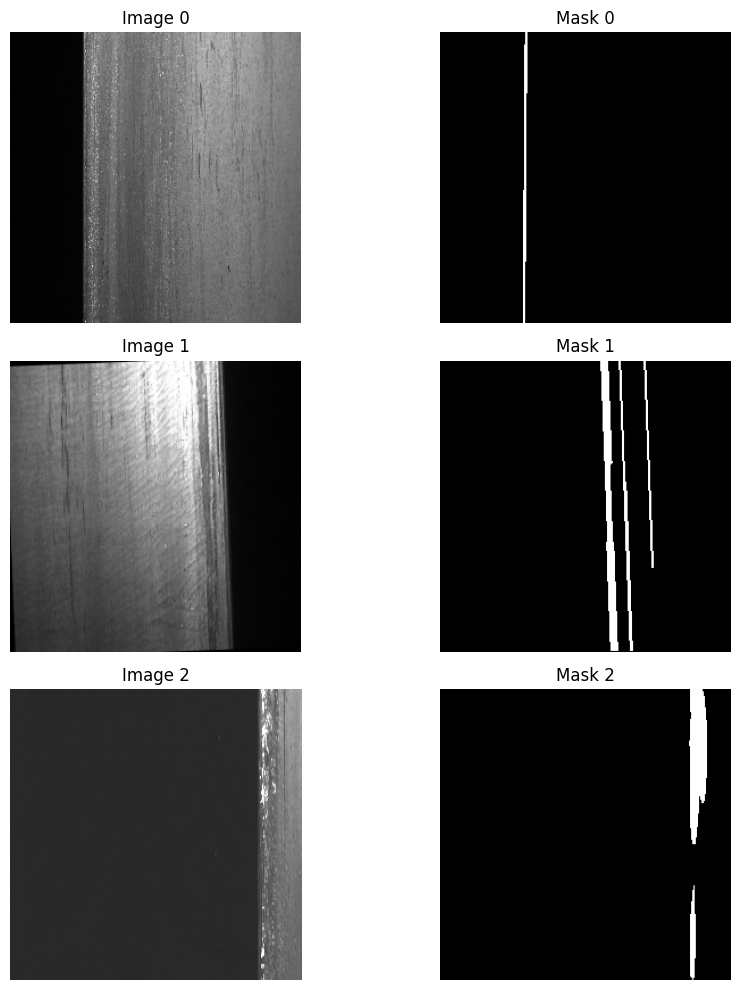

In [172]:
fig, axes = plt.subplots(3, 2, figsize=(10, 10))

for i in range(3):
    img_t, mask_t = train_dataset[i]

    img_np = img_t.permute(1, 2, 0).numpy()
    mean   = np.array([0.485, 0.456, 0.406])
    std    = np.array([0.229, 0.224, 0.225])
    img_np = np.clip(img_np * std + mean, 0, 1)

    axes[i, 0].imshow(img_np)
    axes[i, 0].set_title(f"Image {i}")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(mask_t.squeeze().numpy(), cmap="gray")
    axes[i, 1].set_title(f"Mask {i}")
    axes[i, 1].axis("off")

plt.tight_layout()
plt.show()


## Cell 11 – Mask Pixel Distribution

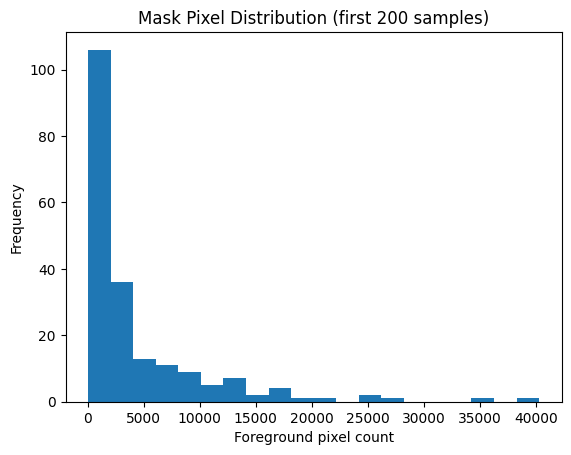

In [173]:
mask_pixels = []

for i in range(200):
    _, mask = train_dataset[i]
    mask_pixels.append(mask.sum().item())

plt.hist(mask_pixels, bins=20)
plt.title("Mask Pixel Distribution (first 200 samples)")
plt.xlabel("Foreground pixel count")
plt.ylabel("Frequency")
plt.show()


## Cell 12 – Baseline UNet (from scratch)

In [174]:
class DoubleConv(nn.Module):
    """Two conv layers each followed by BatchNorm + ReLU."""
    def __init__(self, in_c, out_c):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_c, out_c, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_c, out_c, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.conv(x)


class UNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.pool = nn.MaxPool2d(2)

        self.d1  = DoubleConv(3,   64)
        self.d2  = DoubleConv(64,  128)
        self.d3  = DoubleConv(128, 256)
        self.mid = DoubleConv(256, 512)

        self.u3 = nn.ConvTranspose2d(512, 256, 2, 2)
        self.c3 = DoubleConv(512, 256)

        self.u2 = nn.ConvTranspose2d(256, 128, 2, 2)
        self.c2 = DoubleConv(256, 128)

        self.u1 = nn.ConvTranspose2d(128, 64, 2, 2)
        self.c1 = DoubleConv(128, 64)

        self.out = nn.Conv2d(64, 1, 1)

    def forward(self, x):
        d1 = self.d1(x)
        d2 = self.d2(self.pool(d1))
        d3 = self.d3(self.pool(d2))
        m  = self.mid(self.pool(d3))

        u3 = self.c3(torch.cat([self.u3(m),  d3], 1))
        u2 = self.c2(torch.cat([self.u2(u3), d2], 1))
        u1 = self.c1(torch.cat([self.u1(u2), d1], 1))

        return self.out(u1)


## Cell 13 – ResNet34 UNet (pretrained encoder)

In [175]:
class ResNetUNet(nn.Module):
    def __init__(self):
        super().__init__()
        base = models.resnet34(weights=models.ResNet34_Weights.DEFAULT)

        self.layer0 = nn.Sequential(base.conv1, base.bn1, base.relu)
        self.layer1 = nn.Sequential(base.maxpool, base.layer1)
        self.layer2 = base.layer2
        self.layer3 = base.layer3
        self.layer4 = base.layer4

        self.up4   = nn.ConvTranspose2d(512, 256, 2, 2)
        self.conv4 = DoubleConv(512, 256)

        self.up3   = nn.ConvTranspose2d(256, 128, 2, 2)
        self.conv3 = DoubleConv(256, 128)

        self.up2   = nn.ConvTranspose2d(128, 64, 2, 2)
        self.conv2 = DoubleConv(128, 64)

        self.up1   = nn.ConvTranspose2d(64, 64, 2, 2)
        self.conv1 = DoubleConv(128, 64)

        self.out = nn.Conv2d(64, 1, 1)

        self.final_upsample = nn.Upsample(
            scale_factor=2, mode="bilinear", align_corners=True
        )

    def forward(self, x):
        l0 = self.layer0(x)
        l1 = self.layer1(l0)
        l2 = self.layer2(l1)
        l3 = self.layer3(l2)
        l4 = self.layer4(l3)

        u4 = self.conv4(torch.cat([self.up4(l4), l3], 1))
        u3 = self.conv3(torch.cat([self.up3(u4), l2], 1))
        u2 = self.conv2(torch.cat([self.up2(u3), l1], 1))
        u1 = self.conv1(torch.cat([self.up1(u2), l0], 1))

        return self.final_upsample(self.out(u1))


## Cell 14 – Loss Function (BCE + Dice)

In [176]:
# ── Loss Function (Weighted BCE + Dice) ───────────────────────────────────────

def dice_loss(pred, target, smooth=1e-6):
    pred  = torch.sigmoid(pred)
    inter = (pred * target).sum()
    return 1 - (2 * inter + smooth) / (pred.sum() + target.sum() + smooth)


class CombinedLoss(nn.Module):
    def __init__(self, bce_weight=0.3, dice_weight=0.7, pos_weight=3.0):
        super().__init__()
        # pos_weight > 1 penalises false negatives harder (missed defects)
        self.bce  = nn.BCEWithLogitsLoss(
            pos_weight=torch.tensor([pos_weight]).to(DEVICE)
        )
        self.bw   = bce_weight
        self.dw   = dice_weight

    def forward(self, p, t):
        return self.bw * self.bce(p, t) + self.dw * dice_loss(p, t)

## Cell 15 – Pixel Accuracy Metric

In [177]:
def pixel_accuracy(pred, target):
    with torch.no_grad():
        pred    = (torch.sigmoid(pred) > 0.5).float()
        correct = (pred == target).float().sum()
        total   = target.numel()
    return correct / total


## Cell 16 – Smart Epoch Utilities (EpochPredictor · EarlyStopping · PlateauPruner)

In [178]:
# ═══════════════════════════════════════════════════════════════════════
#  EPOCH PREDICTOR
#  After each epoch, fits a saturation curve to val_dice history and
#  prints how many total epochs are needed to reach `target_dice`.
# ═══════════════════════════════════════════════════════════════════════
class EpochPredictor:
    def __init__(self, target_dice=0.80, max_epochs=MAX_EPOCHS):
        self.target  = target_dice
        self.max_ep  = max_epochs
        self.history = []

    def update(self, epoch, val_dice):
        self.history.append((epoch, val_dice))
        if len(self.history) < 4:
            print(f"    [Predictor] collecting data ({len(self.history)}/4)…")
            return
        self._fit_and_print(epoch)

    def _fit_and_print(self, current_epoch):
        epochs = np.array([h[0] for h in self.history], dtype=float)
        dices  = np.array([h[1] for h in self.history], dtype=float)
        try:
            def sat(e, A, tau, b):
                return A * (1 - np.exp(-e / tau)) + b
            popt, _ = curve_fit(sat, epochs, dices,
                                p0=[dices.max(), current_epoch/2, dices[0]],
                                maxfev=5000,
                                bounds=([0, 1e-3, 0], [1, 1e6, 1]))
            A, tau, b = popt
            for ep in range(current_epoch, self.max_ep + 1):
                if sat(ep, A, tau, b) >= self.target:
                    print(f"    [Predictor] 🎯 Estimated epoch to reach "
                          f"Dice≥{self.target}: ~{ep}  "
                          f"({ep - current_epoch} more)  asymptote≈{A+b:.4f}")
                    return
            print(f"    [Predictor] ⚠️  May not reach Dice={self.target} "
                  f"within {self.max_ep} epochs. Asymptote≈{A+b:.4f}")
        except Exception:
            if len(self.history) >= 2:
                slope = (dices[-1] - dices[0]) / max(epochs[-1]-epochs[0], 1)
                if slope > 1e-6:
                    ep_est = current_epoch + (self.target - dices[-1]) / slope
                    print(f"    [Predictor] 📈 Linear ETA: ~{int(ep_est)} total epochs")
                else:
                    print(f"    [Predictor] ⚠️  Dice is flat — consider changing LR")


# ═══════════════════════════════════════════════════════════════════════
#  EARLY STOPPING
#  Stops training when val_dice hasn't improved by min_delta for
#  `patience` consecutive epochs. Saves the best checkpoint.
# ═══════════════════════════════════════════════════════════════════════
class EarlyStopping:
    def __init__(self, patience=EARLY_STOP_PATIENCE,
                 min_delta=PLATEAU_MIN_DELTA,
                 checkpoint="best_model.pth"):
        self.patience    = patience
        self.min_delta   = min_delta
        self.ckpt        = checkpoint
        self.best        = -np.inf
        self.counter     = 0
        self.should_stop = False

    def step(self, val_dice, model):
        """Returns True = keep training, False = stop."""
        if val_dice > self.best + self.min_delta:
            print(f"    [EarlyStopping] ✅ {self.best:.4f} → {val_dice:.4f}  (saved)")
            self.best    = val_dice
            self.counter = 0
            torch.save(model.state_dict(), self.ckpt)
        else:
            self.counter += 1
            print(f"    [EarlyStopping] No improve {self.counter}/{self.patience}  "
                  f"best={self.best:.4f}")
            if self.counter >= self.patience:
                self.should_stop = True
                print(f"    [EarlyStopping] 🛑 Patience exhausted.")
        return not self.should_stop


# ═══════════════════════════════════════════════════════════════════════
#  PLATEAU PRUNER
#  Detects when rolling avg improvement is too small to continue.
# ═══════════════════════════════════════════════════════════════════════
class PlateauPruner:
    def __init__(self, patience=PLATEAU_PATIENCE, thr=PLATEAU_MIN_DELTA):
        self.patience = patience
        self.thr      = thr
        self.hist     = []

    def step(self, val_dice):
        """Returns True if a plateau is detected."""
        self.hist.append(val_dice)
        if len(self.hist) < self.patience + 1:
            return False
        recent   = self.hist[-(self.patience + 1):]
        avg_gain = np.mean([recent[i+1]-recent[i] for i in range(self.patience)])
        if avg_gain < self.thr:
            print(f"    [PlateauPruner] ⚠️  Avg gain={avg_gain:.6f} < {self.thr}  PLATEAU")
            return True
        return False

print("Smart epoch utilities loaded ✓")


Smart epoch utilities loaded ✓


## Cell 17 – Smart Training Loop (replaces old train_model)

In [179]:
def smart_train(model, train_loader, val_loader, lr=LR, save_path="best_model.pth", device=DEVICE):
    model     = model.to(device)
    criterion = CombinedLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
                    optimizer, mode="max", factor=0.5,
                    patience=PLATEAU_PATIENCE)  # removed verbose=True (deprecated in PyTorch 2.x)

    use_amp = device.type == "cuda"
    scaler  = torch.amp.GradScaler(enabled=use_amp)

    stopper   = EarlyStopping(checkpoint=save_path)
    pruner    = PlateauPruner()
    predictor = EpochPredictor(target_dice=0.80)
    history   = {"train_loss": [], "val_loss": [], "val_dice": [], "val_acc": []}
    lr_drops  = 0

    print(f"\n{'='*58}")
    print(f"  Smart Training  |  max={MAX_EPOCHS}  min={MIN_EPOCHS} epochs")
    print(f"  Early-stop patience : {EARLY_STOP_PATIENCE} epochs")
    print(f"  Plateau patience    : {PLATEAU_PATIENCE} epochs")
    print(f"{'='*58}\n")

    for epoch in range(1, MAX_EPOCHS + 1):
        cur_lr = optimizer.param_groups[0]["lr"]
        print(f"── Epoch {epoch}/{MAX_EPOCHS}   LR={cur_lr:.2e} ──")

        # ── Train ───────────────────────────────────────────────────────────
        model.train()
        train_loss = 0.0
        for imgs, masks in tqdm(train_loader, leave=False, desc="  train"):
            imgs, masks = imgs.to(device), masks.to(device)
            optimizer.zero_grad()
            with torch.amp.autocast(device_type=device.type, enabled=use_amp):
                out  = model(imgs)
                loss = criterion(out, masks)
            scaler.scale(loss).backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
            train_loss += loss.item()

        # ── Validate ────────────────────────────────────────────────────────
        model.eval()
        val_loss = val_dice_total = val_acc_total = 0.0
        with torch.no_grad():
            for imgs, masks in tqdm(val_loader, leave=False, desc="  val"):
                imgs, masks = imgs.to(device), masks.to(device)
                out  = model(imgs)
                val_loss += criterion(out, masks).item()
                pred_bin  = (torch.sigmoid(out) > 0.5).float()
                inter     = (pred_bin * masks).sum()
                val_dice_total += ((2*inter + 1e-6) / (pred_bin.sum() + masks.sum() + 1e-6)).item()
                val_acc_total  += pixel_accuracy(out, masks).item()

        n  = len(val_loader)
        tl = train_loss / len(train_loader)
        vl = val_loss / n
        vd = val_dice_total / n
        va = val_acc_total / n

        history["train_loss"].append(tl)
        history["val_loss"].append(vl)
        history["val_dice"].append(vd)
        history["val_acc"].append(va)

        print(f"  train_loss={tl:.4f}  val_loss={vl:.4f}  "
              f"val_dice={vd:.4f}  val_acc={va:.4f}")

        # 1 ── Epoch predictor
        predictor.update(epoch, vd)

        # 2 ── Scheduler step + manual LR-drop log
        prev_lr = optimizer.param_groups[0]["lr"]
        scheduler.step(vd)
        new_lr = optimizer.param_groups[0]["lr"]
        if new_lr < prev_lr:
            lr_drops += 1
            print(f"    [Scheduler] 📉 LR {prev_lr:.2e} → {new_lr:.2e}  (drop #{lr_drops})")
            if lr_drops >= 3 and epoch >= MIN_EPOCHS:
                print("    [SmartTrain] 🛑 3× LR reductions with no gain — pruning run.")
                break

        # 3 ── Plateau pruner
        if pruner.step(vd) and epoch >= MIN_EPOCHS:
            if optimizer.param_groups[0]["lr"] < LR * 0.05:
                print("    [SmartTrain] 🛑 Plateau + min-LR reached — pruning.")
                break

        # 4 ── Early stopping
        if not stopper.step(vd, model) and epoch >= MIN_EPOCHS:
            print(f"\n  Best Val Dice = {stopper.best:.4f}")
            break

        print()

    # ── Load best weights ───────────────────────────────────────────────────
    if os.path.exists(save_path):
        model.load_state_dict(torch.load(save_path, map_location=device, weights_only=True))
        print(f"\n  Loaded best checkpoint  (Val Dice={stopper.best:.4f})")

    ep_done = len(history["train_loss"])
    print(f"\n{'='*58}")
    print(f"  Done: {ep_done}/{MAX_EPOCHS} epochs used")
    print(f"  Best Val Dice : {max(history['val_dice']):.4f}")
    print(f"  Best Val Acc  : {max(history['val_acc']):.4f}")
    print(f"{'='*58}")
    return model, history

## Cell 18 – Run Training

In [180]:
print("Training ResNetUNet with Smart Epoch Pruning…")
resnet, history = smart_train(
    ResNetUNet(),
    train_loader,
    val_loader,
    lr=1e-4,
    save_path="resnet.pth",
    device=DEVICE
)


Training ResNetUNet with Smart Epoch Pruning…

  Smart Training  |  max=30  min=5 epochs
  Early-stop patience : 7 epochs
  Plateau patience    : 4 epochs

── Epoch 1/30   LR=1.00e-04 ──


  train:   0%|          | 0/112 [00:00<?, ?it/s]

  val:   0%|          | 0/28 [00:00<?, ?it/s]

  train_loss=1.3729  val_loss=1.1865  val_dice=0.5158  val_acc=0.9407
    [Predictor] collecting data (1/4)…
    [EarlyStopping] ✅ -inf → 0.5158  (saved)

── Epoch 2/30   LR=1.00e-04 ──


  train:   0%|          | 0/112 [00:00<?, ?it/s]

...

  val:   0%|          | 0/28 [00:00<?, ?it/s]

  train_loss=0.4224  val_loss=0.4790  val_dice=0.6905  val_acc=0.9637
    [Predictor] ⚠️  May not reach Dice=0.8 within 30 epochs. Asymptote≈0.6891
    [EarlyStopping] No improve 6/7  best=0.6912

── Epoch 28/30   LR=5.00e-05 ──


  train:   0%|          | 0/112 [00:00<?, ?it/s]

  val:   0%|          | 0/28 [00:00<?, ?it/s]

  train_loss=0.4191  val_loss=0.4772  val_dice=0.6910  val_acc=0.9643
    [Predictor] ⚠️  May not reach Dice=0.8 within 30 epochs. Asymptote≈0.6895
    [EarlyStopping] No improve 7/7  best=0.6912
    [EarlyStopping] 🛑 Patience exhausted.

  Best Val Dice = 0.6912

  Loaded best checkpoint  (Val Dice=0.6912)

  Done: 28/30 epochs used
  Best Val Dice : 0.6912
  Best Val Acc  : 0.9648


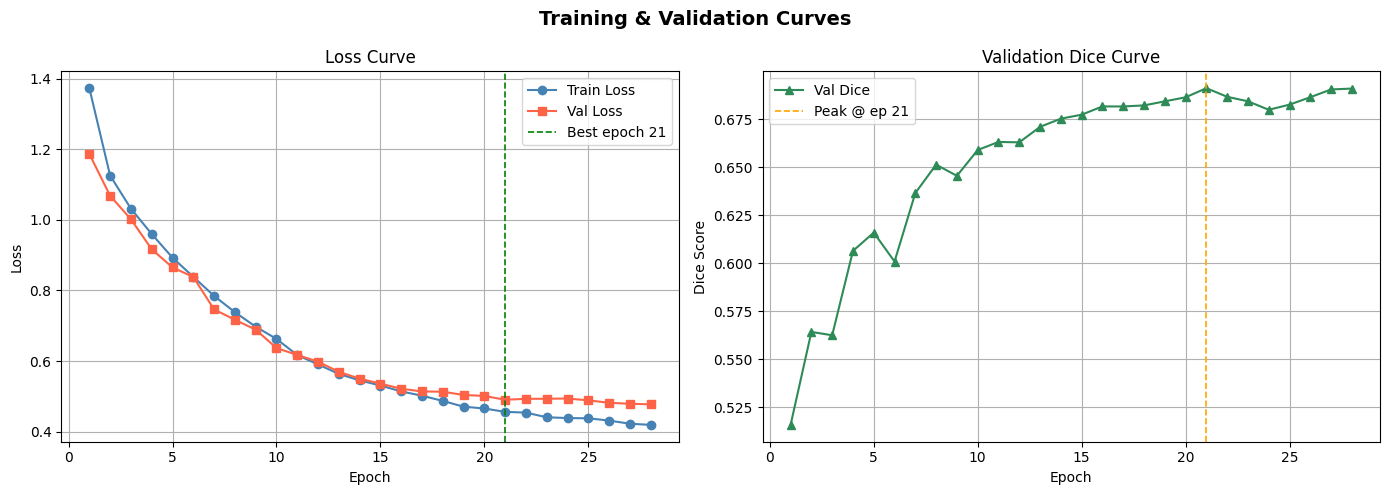

Best Val Dice: 0.6912 at epoch 21


In [191]:
# ── Training & Validation Curves ─────────────────────────────────────────────
import matplotlib.pyplot as plt

EP = list(range(1, len(history["train_loss"]) + 1))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(EP, history["train_loss"], "o-", label="Train Loss", color="steelblue")
axes[0].plot(EP, history["val_loss"],   "s-", label="Val Loss",   color="tomato")
axes[0].set_title("Loss Curve")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].legend(); axes[0].grid(True)

best_ep = int(np.argmax(history["val_dice"])) + 1
axes[0].axvline(best_ep, color="green", linestyle="--", linewidth=1.2, label=f"Best epoch {best_ep}")
axes[0].legend()

# Dice
axes[1].plot(EP, history["val_dice"], "^-", label="Val Dice", color="seagreen")
axes[1].axvline(best_ep, color="orange", linestyle="--", linewidth=1.2, label=f"Peak @ ep {best_ep}")
axes[1].set_title("Validation Dice Curve")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Dice Score")
axes[1].legend(); axes[1].grid(True)

plt.suptitle("Training & Validation Curves", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("train_val_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Best Val Dice: {max(history['val_dice']):.4f} at epoch {best_ep}")

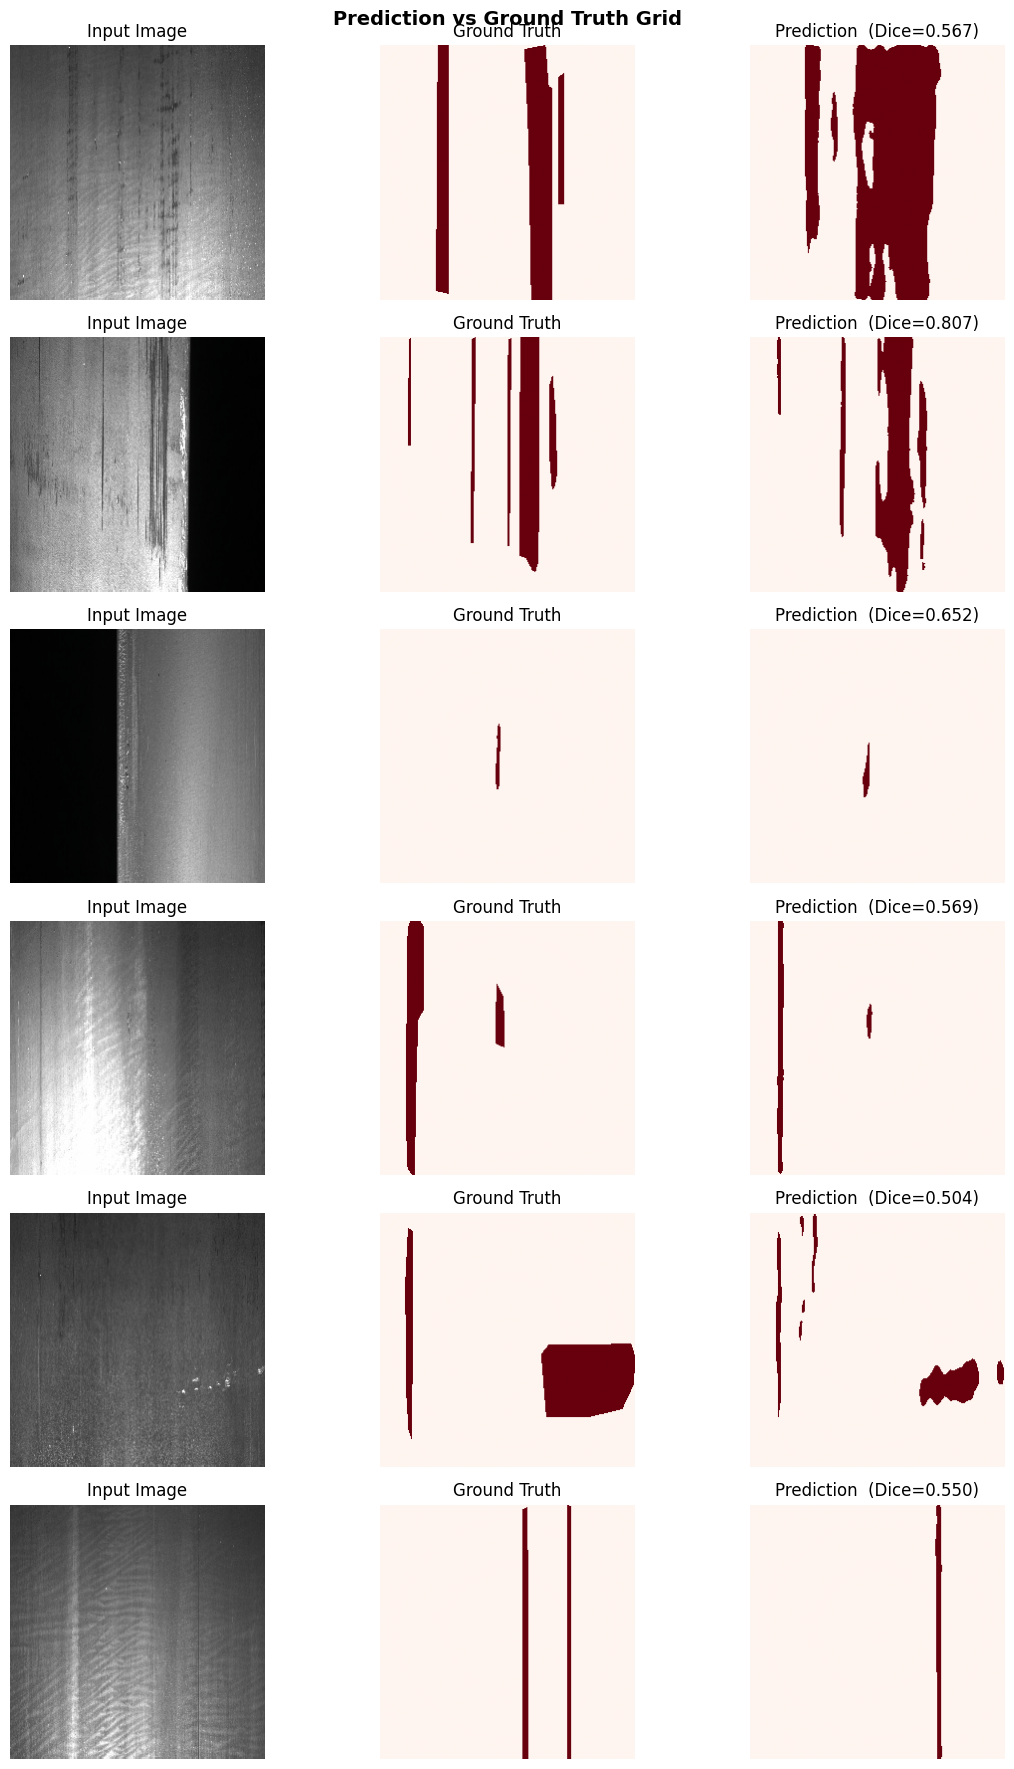

In [192]:
# ── Prediction vs Ground Truth Grid ──────────────────────────────────────────
resnet.eval()
imgs_g, masks_g = next(iter(val_loader))
imgs_g = imgs_g.to(DEVICE)

with torch.no_grad():
    preds_g = torch.sigmoid(resnet(imgs_g)).cpu()

mean_np = np.array([0.485, 0.456, 0.406])
std_np  = np.array([0.229, 0.224, 0.225])

N = 6  # number of samples to show
fig, axes = plt.subplots(N, 3, figsize=(12, N * 3))
fig.suptitle("Prediction vs Ground Truth Grid", fontsize=14, fontweight="bold")

for i in range(N):
    img_np   = np.clip(imgs_g[i].cpu().permute(1,2,0).numpy() * std_np + mean_np, 0, 1)
    gt_np    = masks_g[i].squeeze().numpy()
    pred_np  = (preds_g[i].squeeze().numpy() > 0.5).astype(np.uint8)

    dice_i = (2 * (pred_np * gt_np).sum() + 1e-6) / (pred_np.sum() + gt_np.sum() + 1e-6)

    axes[i, 0].imshow(img_np);                   axes[i, 0].set_title("Input Image")
    axes[i, 1].imshow(gt_np,   cmap="Reds");     axes[i, 1].set_title("Ground Truth")
    axes[i, 2].imshow(pred_np, cmap="Reds");     axes[i, 2].set_title(f"Prediction  (Dice={dice_i:.3f})")
    for ax in axes[i]: ax.axis("off")

plt.tight_layout()
plt.savefig("pred_vs_gt_grid.png", dpi=150, bbox_inches="tight")
plt.show()

In [193]:
for name, module in resnet.named_modules():
    print(name)


layer0
layer0.0
layer0.1
layer0.2
layer1
layer1.0
layer1.1
layer1.1.0
layer1.1.0.conv1
layer1.1.0.bn1
layer1.1.0.relu
layer1.1.0.conv2
layer1.1.0.bn2
layer1.1.1
layer1.1.1.conv1
layer1.1.1.bn1
layer1.1.1.relu
layer1.1.1.conv2
layer1.1.1.bn2
layer1.1.2
layer1.1.2.conv1
layer1.1.2.bn1
layer1.1.2.relu
layer1.1.2.conv2
layer1.1.2.bn2
layer2
layer2.0
layer2.0.conv1
layer2.0.bn1
layer2.0.relu
layer2.0.conv2
layer2.0.bn2
layer2.0.downsample
layer2.0.downsample.0
layer2.0.downsample.1
layer2.1
layer2.1.conv1
layer2.1.bn1
layer2.1.relu
layer2.1.conv2
layer2.1.bn2
layer2.2
layer2.2.conv1
layer2.2.bn1
layer2.2.relu
layer2.2.conv2
layer2.2.bn2
layer2.3
layer2.3.conv1
layer2.3.bn1
layer2.3.relu
layer2.3.conv2
layer2.3.bn2
layer3
layer3.0
layer3.0.conv1
layer3.0.bn1
layer3.0.relu
layer3.0.conv2
layer3.0.bn2
layer3.0.downsample
layer3.0.downsample.0
layer3.0.downsample.1
layer3.1
layer3.1.conv1
layer3.1.bn1
layer3.1.relu
layer3.1.conv2
layer3.1.bn2
layer3.2
layer3.2.conv1
layer3.2.bn1
layer3.2.relu


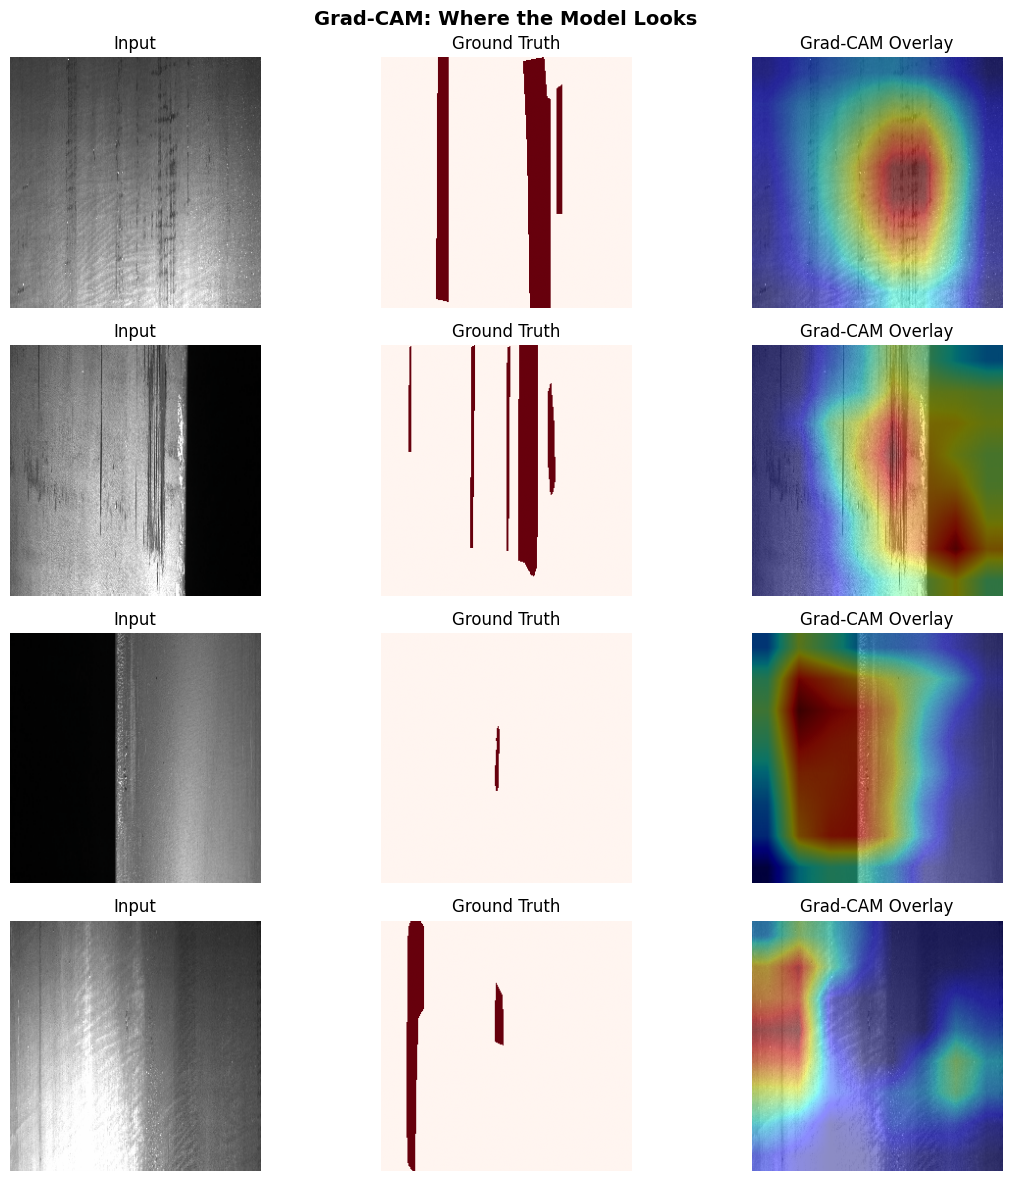

In [194]:
# ── Grad-CAM on ResNet-based UNet ────────────────────────────────────────────
# Hooks the last encoder conv layer to show what spatial regions drive predictions

from torch.nn.functional import interpolate

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.gradients = None
        self.activations = None
        target_layer.register_forward_hook(self._save_activation)
        target_layer.register_full_backward_hook(self._save_gradient)

    def _save_activation(self, module, inp, out):
        self.activations = out.detach()

    def _save_gradient(self, module, grad_in, grad_out):
        self.gradients = grad_out[0].detach()

    def generate(self, input_tensor):
        self.model.zero_grad()
        output = self.model(input_tensor)
        score = torch.sigmoid(output).mean()
        score.backward()
        weights = self.gradients.mean(dim=[2, 3], keepdim=True)
        cam = (weights * self.activations).sum(dim=1, keepdim=True)
        cam = torch.relu(cam)
        cam = interpolate(cam, size=input_tensor.shape[-2:], mode="bilinear", align_corners=False)
        cam = cam.squeeze().cpu().numpy()
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam

# Target the last conv in ResNet encoder (layer4)
target_layer = resnet.layer4[2].conv2

gcam = GradCAM(resnet, target_layer)

mean_np = np.array([0.485, 0.456, 0.406])
std_np  = np.array([0.229, 0.224, 0.225])

imgs_g, masks_g = next(iter(val_loader))
N_CAM = 4

fig, axes = plt.subplots(N_CAM, 3, figsize=(12, N_CAM * 3))
fig.suptitle("Grad-CAM: Where the Model Looks", fontsize=14, fontweight="bold")

for i in range(N_CAM):
    inp = imgs_g[i:i+1].to(DEVICE).requires_grad_(True)
    cam = gcam.generate(inp)

    img_np = np.clip(imgs_g[i].permute(1,2,0).numpy() * std_np + mean_np, 0, 1)
    gt_np  = masks_g[i].squeeze().numpy()

    heatmap = plt.cm.jet(cam)[..., :3]
    overlay = 0.55 * img_np + 0.45 * heatmap

    axes[i, 0].imshow(img_np);              axes[i, 0].set_title("Input")
    axes[i, 1].imshow(gt_np, cmap="Reds"); axes[i, 1].set_title("Ground Truth")
    axes[i, 2].imshow(overlay);            axes[i, 2].set_title("Grad-CAM Overlay")
    for ax in axes[i]: ax.axis("off")

plt.tight_layout()
plt.savefig("gradcam.png", dpi=150, bbox_inches="tight")
plt.show()

## Cell 19 – Quick Prediction Preview

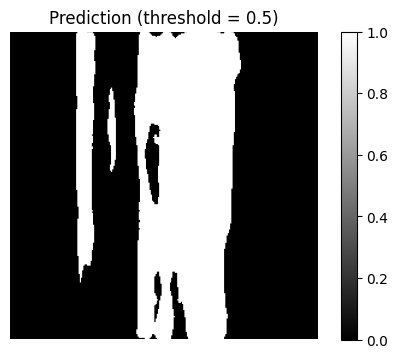

In [181]:
resnet.eval()

imgs, masks = next(iter(val_loader))
imgs = imgs.to(DEVICE)

with torch.no_grad():
    preds = torch.sigmoid(resnet(imgs))

plt.figure(figsize=(6, 4))
plt.imshow(preds[0].cpu().squeeze() > 0.5, cmap="gray")
plt.title("Prediction (threshold = 0.5)")
plt.axis("off")
plt.colorbar()
plt.show()


## Cell 20 – Overlay Visualisation

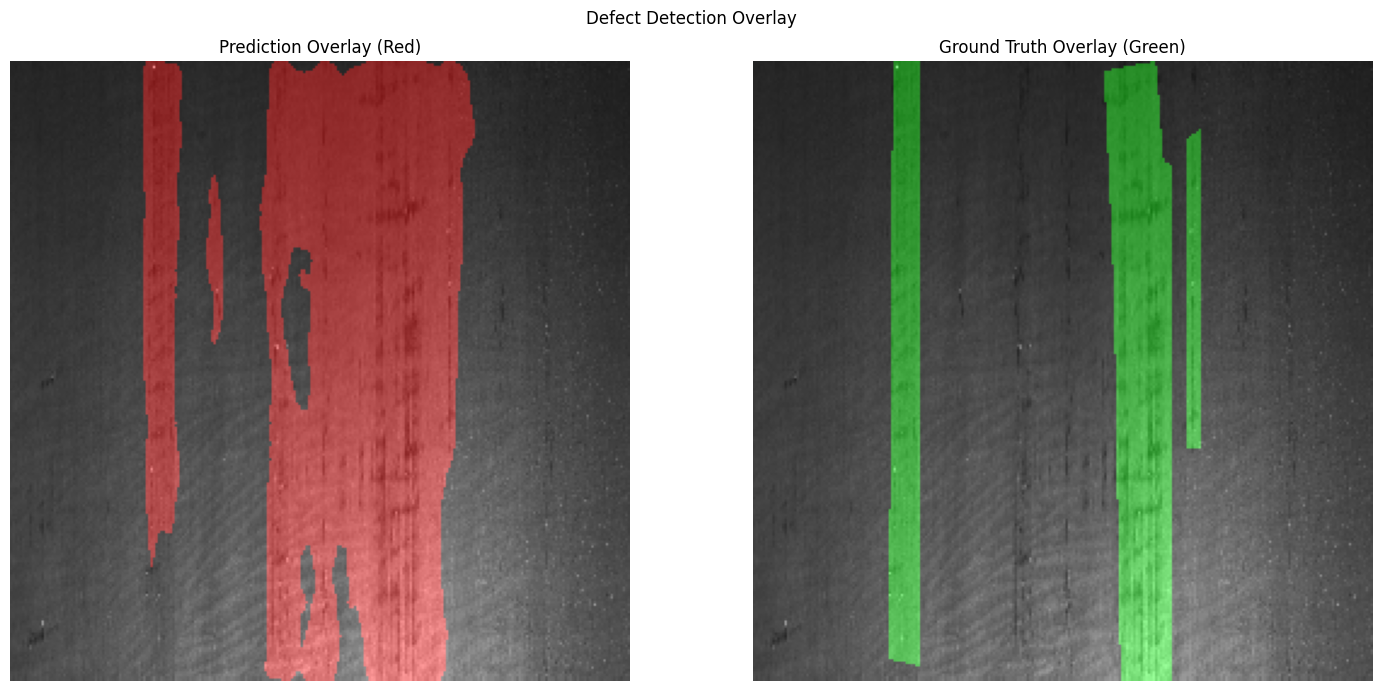

In [182]:
def plot_overlay(img_t, mask_t, pred_t, title="Defect Detection Overlay"):
    img  = img_t.cpu().permute(1, 2, 0).numpy()
    mask = mask_t.cpu().squeeze().numpy()
    pred = (torch.sigmoid(pred_t).cpu().squeeze() > 0.5).numpy()

    mean = np.array([0.485, 0.456, 0.406])
    std  = np.array([0.229, 0.224, 0.225])
    img  = np.clip(img * std + mean, 0, 1)

    pred_overlay = np.zeros_like(img)
    pred_overlay[pred == 1] = [1, 0, 0]

    gt_overlay = np.zeros_like(img)
    gt_overlay[mask == 1] = [0, 1, 0]

    fig, ax = plt.subplots(1, 2, figsize=(15, 7))
    ax[0].imshow(img); ax[0].imshow(pred_overlay, alpha=0.4)
    ax[0].set_title("Prediction Overlay (Red)"); ax[0].axis("off")

    ax[1].imshow(img); ax[1].imshow(gt_overlay, alpha=0.4)
    ax[1].set_title("Ground Truth Overlay (Green)"); ax[1].axis("off")

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


imgs_v, masks_v = next(iter(val_loader))
out_v = resnet(imgs_v.to(DEVICE))
plot_overlay(imgs_v[0], masks_v[0], out_v[0].detach().cpu())


## Cell 21 – Load Saved Model & Evaluate

In [183]:
resnet = ResNetUNet()
resnet.load_state_dict(
    torch.load("resnet.pth", map_location=DEVICE, weights_only=True)
)
resnet = resnet.to(DEVICE)
resnet.eval()
print("Model loaded successfully.")


Model loaded successfully.


## Cell 23 – Training History Plots

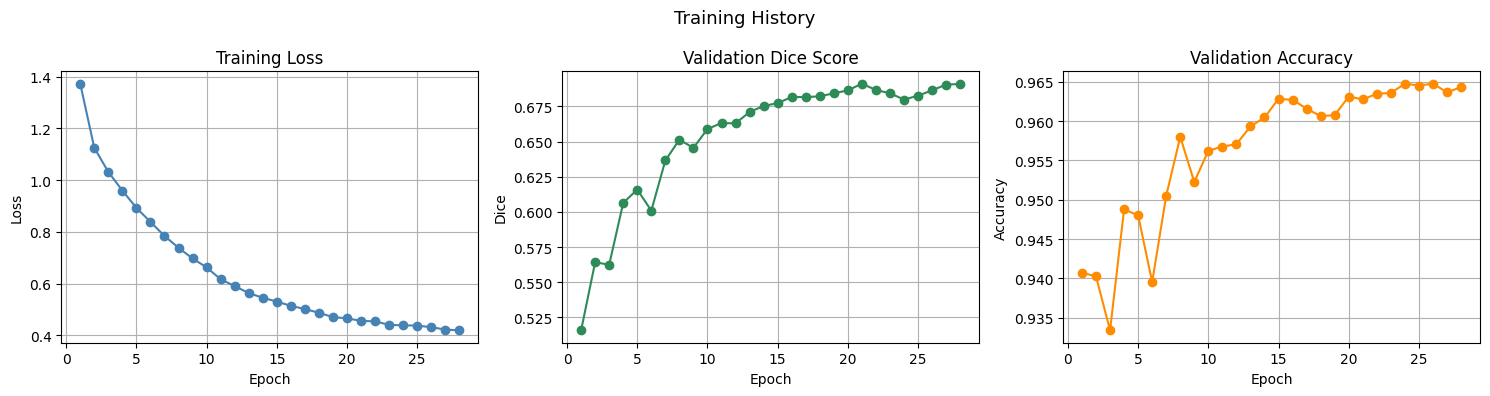

In [185]:
epochs_range = range(1, len(history["train_loss"]) + 1)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(epochs_range, history["train_loss"], marker="o", color="steelblue")
axes[0].set_title("Training Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].grid(True)

axes[1].plot(epochs_range, history["val_dice"], marker="o", color="seagreen")
axes[1].set_title("Validation Dice Score")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Dice")
axes[1].grid(True)

axes[2].plot(epochs_range, history["val_acc"], marker="o", color="darkorange")
axes[2].set_title("Validation Accuracy")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("Accuracy")
axes[2].grid(True)

plt.suptitle("Training History", fontsize=13)
plt.tight_layout()
plt.show()


## Cell 24 – Confusion Matrix & Metrics

Precision : 0.6758
Recall    : 0.7146
F1 Score  : 0.6947


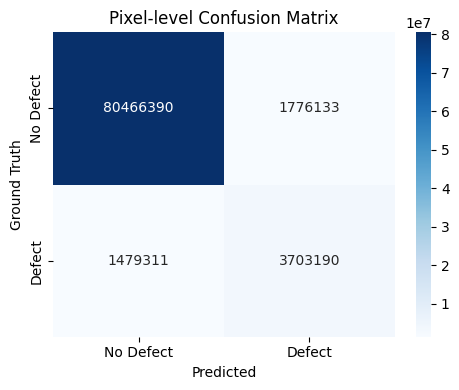

In [186]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score
import seaborn as sns

resnet.eval()
all_preds  = []
all_labels = []

with torch.no_grad():
    for imgs, masks in val_loader:
        imgs  = imgs.to(DEVICE)
        preds = (torch.sigmoid(resnet(imgs)) > 0.5).float()
        all_preds.append(preds.cpu().numpy().flatten())
        all_labels.append(masks.numpy().flatten())

all_preds  = np.concatenate(all_preds).astype(int)
all_labels = np.concatenate(all_labels).astype(int)

precision = precision_score(all_labels, all_preds, zero_division=0)
recall    = recall_score(all_labels, all_preds, zero_division=0)
f1        = f1_score(all_labels, all_preds, zero_division=0)
cm        = confusion_matrix(all_labels, all_preds)

print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Defect", "Defect"],
            yticklabels=["No Defect", "Defect"])
plt.title("Pixel-level Confusion Matrix")
plt.ylabel("Ground Truth")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()


## Cell 25 – Single-Image Inference (Deployment Ready)

In [187]:
def predict_single_image(image_path, model, threshold=0.5):
    """
    Takes a raw image path, returns the defect mask and overlay.
    Ready for deployment — can be wrapped in a Flask/FastAPI endpoint.
    """
    model.eval()

    img = cv2.imread(image_path)
    if img is None:
        raise FileNotFoundError(f"Image not found: {image_path}")
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    tfm = A.Compose([
        A.Resize(256, 256),
        A.Normalize(mean=(0.485, 0.456, 0.406),
                    std =(0.229, 0.224, 0.225)),
        ToTensorV2()
    ])
    tensor = tfm(image=img)["image"].unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        prob = torch.sigmoid(model(tensor)).cpu().squeeze().numpy()

    mask = (prob > threshold).astype(np.uint8)
    defect_ratio = mask.mean() * 100

    mean = np.array([0.485, 0.456, 0.406])
    std  = np.array([0.229, 0.224, 0.225])
    img_display = np.clip(
        tensor.cpu().squeeze().permute(1,2,0).numpy() * std + mean, 0, 1
    )

    overlay = img_display.copy()
    overlay[mask == 1] = overlay[mask == 1] * 0.5 + np.array([1,0,0]) * 0.5

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    axes[0].imshow(img_display);  axes[0].set_title("Input Image");      axes[0].axis("off")
    axes[1].imshow(mask, cmap="gray"); axes[1].set_title(f"Defect Mask ({defect_ratio:.1f}% pixels)"); axes[1].axis("off")
    axes[2].imshow(overlay);      axes[2].set_title("Overlay");          axes[2].axis("off")
    plt.suptitle(f"Inference: {'DEFECT DETECTED' if defect_ratio > 0 else 'NO DEFECT'}", fontsize=13,
                 color="red" if defect_ratio > 0 else "green")
    plt.tight_layout()
    plt.show()

    return mask, prob, defect_ratio

# Example usage:
# mask, prob, ratio = predict_single_image("/kaggle/input/.../test_images/abc.jpg", resnet)


## Cell 26 – Project Summary Dashboard

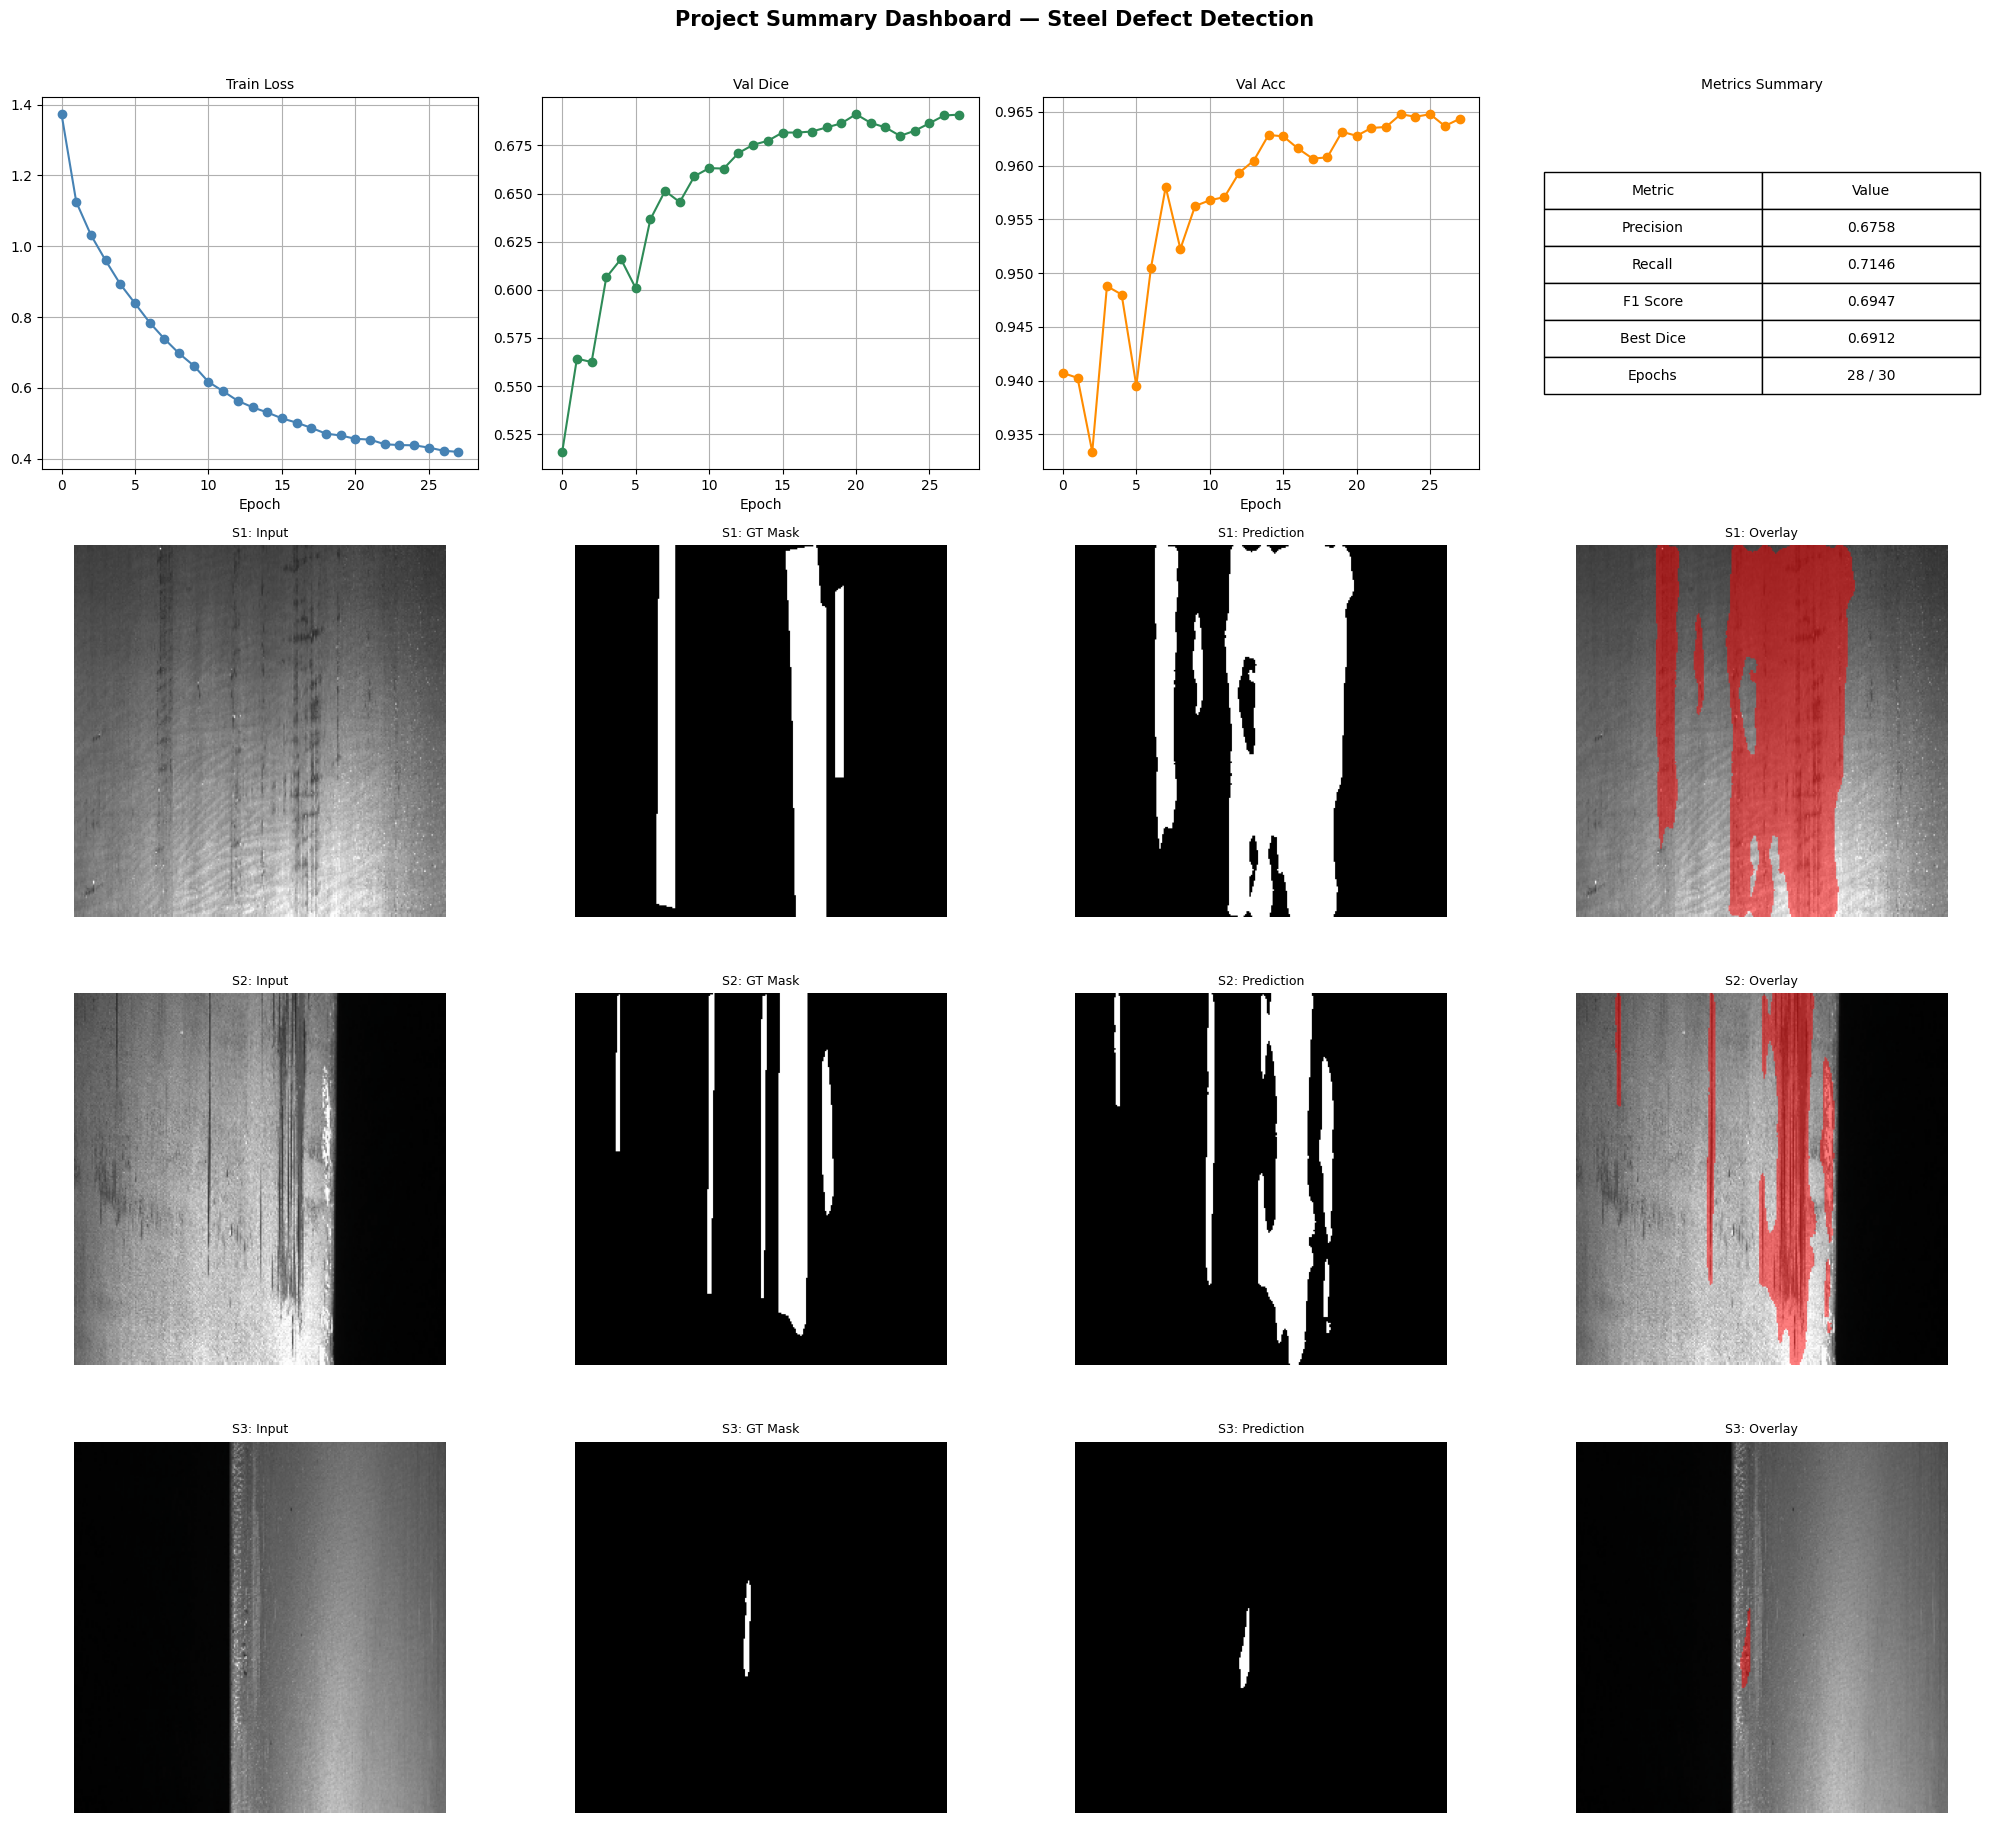

Dashboard saved as dashboard.png


In [188]:
resnet.eval()
imgs_d, masks_d = next(iter(val_loader))
imgs_d = imgs_d.to(DEVICE)

with torch.no_grad():
    preds_d = torch.sigmoid(resnet(imgs_d)).cpu()

mean = np.array([0.485, 0.456, 0.406])
std  = np.array([0.229, 0.224, 0.225])

fig = plt.figure(figsize=(20, 18))
fig.suptitle("Project Summary Dashboard — Steel Defect Detection", fontsize=15, fontweight="bold", y=1.01)

for idx, (key, label, color) in enumerate([
    ("train_loss", "Train Loss", "steelblue"),
    ("val_dice",   "Val Dice",   "seagreen"),
    ("val_acc",    "Val Acc",    "darkorange")
]):
    ax = fig.add_subplot(4, 4, idx + 1)
    ax.plot(history[key], marker="o", color=color)
    ax.set_title(label, fontsize=10)
    ax.set_xlabel("Epoch"); ax.grid(True)

ax_m = fig.add_subplot(4, 4, 4)
ax_m.axis("off")
table_data = [
    ["Precision", f"{precision:.4f}"],
    ["Recall",    f"{recall:.4f}"],
    ["F1 Score",  f"{f1:.4f}"],
    ["Best Dice", f"{max(history['val_dice']):.4f}"],
    ["Epochs",    f"{len(history['val_dice'])} / {MAX_EPOCHS}"],
]
t = ax_m.table(cellText=table_data, colLabels=["Metric", "Value"],
               loc="center", cellLoc="center")
t.auto_set_font_size(False); t.set_fontsize(10); t.scale(1, 1.8)
ax_m.set_title("Metrics Summary", fontsize=10)

for i in range(3):
    img_np   = np.clip(imgs_d[i].cpu().permute(1,2,0).numpy() * std + mean, 0, 1)
    gt_np    = masks_d[i].squeeze().numpy()
    pred_np  = (preds_d[i].squeeze().numpy() > 0.5).astype(np.uint8)

    overlay = img_np.copy()
    overlay[pred_np == 1] = overlay[pred_np == 1] * 0.5 + np.array([1,0,0]) * 0.5

    base = 5 + i * 4
    for j, (im, title, cmap) in enumerate([
        (img_np,  "Input",      None),
        (gt_np,   "GT Mask",    "gray"),
        (pred_np, "Prediction", "gray"),
        (overlay, "Overlay",    None),
    ]):
        ax = fig.add_subplot(4, 4, base + j)
        ax.imshow(im, cmap=cmap)
        ax.set_title(f"S{i+1}: {title}", fontsize=9)
        ax.axis("off")

plt.tight_layout()
plt.savefig("dashboard.png", dpi=150, bbox_inches="tight")
plt.show()
print("Dashboard saved as dashboard.png")
